# MiniClaw — Live Demo**Team:** David Ricciotti, Haben Berhe, Yoel Tesfatsion  **Design:** Haben's crossed-branch four-bar linkage  **Architecture:** Architecture A — single 20T spur pair---## Part 1: Four-Bar Linkage SimulationHaben's linkage (L1=47, L2=20, L3=29, L4=23 mm) sweeping from −50° to +50°.Each frame shows the current jaw opening and transmission angle margin.

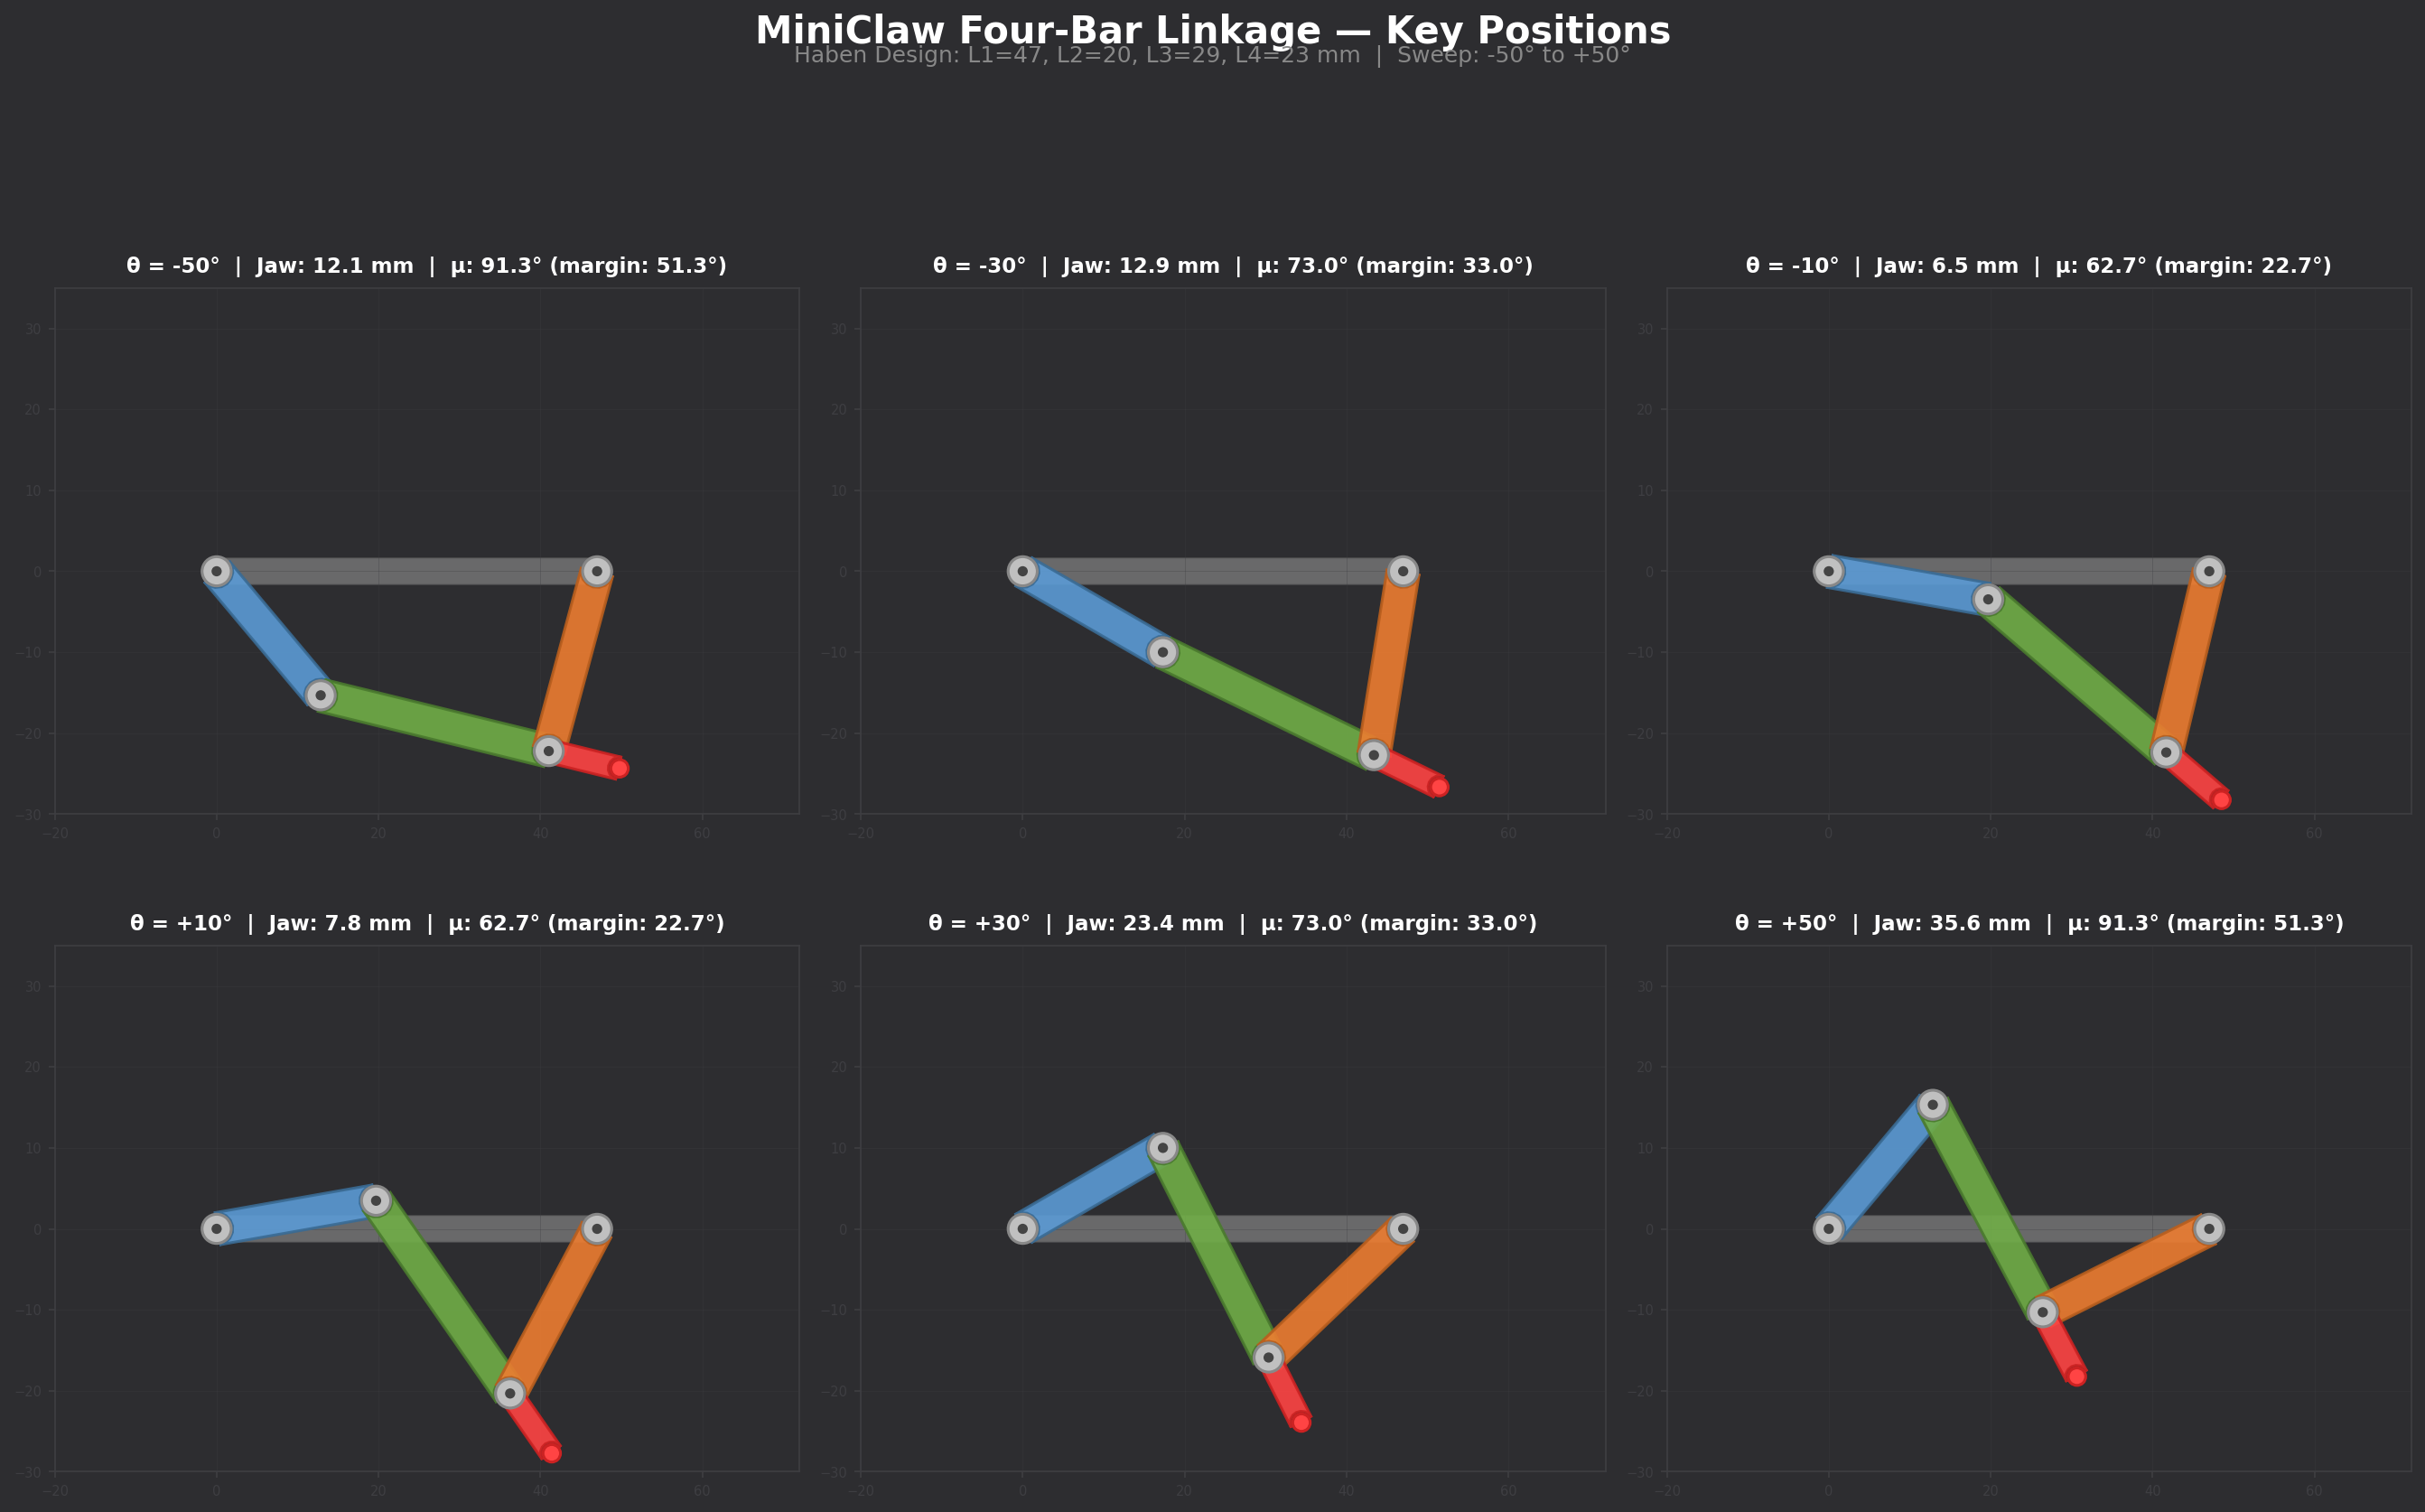

In [ ]:
# MiniClaw Four-Bar Linkage — Key Positions
# Haben's design: L1=47, L2=20, L3=29, L4=23 mm
# Sweep: -50° to +50° | Jaw opening: 0 → 40 mm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon

L1, L2, L3, L4 = 47.0, 20.0, 29.0, 23.0
O2, O4 = np.array([0., 0.]), np.array([47., 0.])
TIP_EXT = 9.0

def solve(theta_deg):
    theta = np.radians(theta_deg)
    A = O2 + L2 * np.array([np.cos(theta), np.sin(theta)])
    dx, dy = O4[0]-A[0], O4[1]-A[1]
    d = np.sqrt(dx**2 + dy**2)
    cos_a = np.clip((L3**2+d**2-L4**2)/(2*L3*d), -1, 1)
    alpha = np.arccos(cos_a)
    base = np.arctan2(dy, dx)
    theta3 = base - alpha
    B = A + L3*np.array([np.cos(theta3), np.sin(theta3)])
    cos_mu = np.clip((L3**2+L4**2-d**2)/(2*L3*L4), -1, 1)
    mu = np.degrees(np.arccos(cos_mu))
    tip = B + TIP_EXT*(B-A)/np.linalg.norm(B-A)
    return A, B, tip, mu

def link_poly(p1, p2, w=4.0):
    d = p2-p1; L = np.linalg.norm(d)
    perp = np.array([-d[1],d[0]])/L*w/2
    pts = []
    ab = np.arctan2(-perp[1],-perp[0])
    for i in range(9): pts.append(p1+w/2*np.array([np.cos(ab+np.pi*i/8),np.sin(ab+np.pi*i/8)]))
    ab2 = np.arctan2(perp[1],perp[0])
    for i in range(9): pts.append(p2+w/2*np.array([np.cos(ab2+np.pi*i/8),np.sin(ab2+np.pi*i/8)]))
    return np.array(pts)

ref_tip = solve(0)[2]
fig, axes = plt.subplots(2,3,figsize=(18,12),facecolor='#2D2D30')
fig.suptitle('MiniClaw Four-Bar Linkage — Key Positions',fontsize=20,fontweight='bold',color='w',y=.98)
fig.text(.5,.95,'L1=47, L2=20, L3=29, L4=23 mm | Sweep: -50° to +50°',fontsize=12,color='#888',ha='center')
for idx,theta in enumerate([-50,-30,-10,10,30,50]):
    ax=axes[idx//3][idx%3]; ax.set_facecolor('#2D2D30')
    ax.set_xlim(-20,72); ax.set_ylim(-30,35); ax.set_aspect('equal')
    ax.grid(True,color='#3E3E42',lw=.3,alpha=.5)
    ax.tick_params(colors='#3E3E42',labelsize=7)
    for s in ax.spines.values(): s.set_color('#3E3E42')
    A,B,tip,mu = solve(theta)
    disp = np.linalg.norm(tip-ref_tip)
    # Ground
    ax.add_patch(Polygon(link_poly(O2,O4,3.2),closed=True,fc='#A5A5A5',ec='#666',lw=1,alpha=.5,zorder=1))
    # Links
    for p1,p2,c,ec in [(O2,A,'#5B9BD5','#3A6B94'),(A,B,'#70AD47','#4A7A2E'),(O4,B,'#ED7D31','#B85E1E')]:
        ax.add_patch(Polygon(link_poly(p1,p2),closed=True,fc=c,ec=ec,lw=1.5,zorder=3,alpha=.9))
    ax.add_patch(Polygon(link_poly(B,tip,2.8),closed=True,fc='#FF4444',ec='#CC2222',lw=1.5,zorder=4,alpha=.9))
    for p in [O2,A,B,O4]:
        ax.add_patch(Circle(p,1.8,fc='#C0C0C0',ec='#888',lw=1.5,zorder=5))
        ax.add_patch(Circle(p,.63,fc='#444',ec='none',zorder=6))
    ax.add_patch(Circle(tip,1.08,fc='#FF4444',ec='#CC2222',lw=1.5,zorder=6))
    m=mu-40; mc='#70AD47' if m>15 else('#FFD966' if m>5 else'#FF4444')
    ax.set_title(f'θ={theta:+d}° | Jaw:{2*disp:.1f}mm | μ:{mu:.1f}° (margin:{m:.1f}°)',fontsize=11,fontweight='bold',color='w',pad=8)
plt.tight_layout(rect=[0,0,1,.93])
plt.show()


---## Part 2: Live Tool Call — `compute_transmission_angle()`What happens when we change one link length by just 3 mm?

In [ ]:
def compute_transmission_angle(L1, L2, L3, L4, O4_x, theta_min=-50, theta_max=50):
    """Compute transmission angle across input range for a four-bar linkage."""
    O2 = np.array([0.0, 0.0])
    O4 = np.array([O4_x, 0.0])
    mus = []
    for theta_deg in np.linspace(theta_min, theta_max, 200):
        theta = np.radians(theta_deg)
        A = O2 + L2 * np.array([np.cos(theta), np.sin(theta)])
        dx, dy = O4[0]-A[0], O4[1]-A[1]
        d = np.sqrt(dx**2 + dy**2)
        if d > L3+L4 or d < abs(L3-L4): continue
        cos_mu = np.clip((L3**2+L4**2-d**2)/(2*L3*L4), -1, 1)
        mus.append(np.degrees(np.arccos(cos_mu)))
    mu_min, mu_max = min(mus), max(mus)
    margin = mu_min - 40
    in_band = mu_min >= 40 and mu_max <= 140
    return {'mu_min': mu_min, 'mu_max': mu_max, 'margin': margin, 'in_band': in_band}

print('='*60)
print('MiniClaw Transmission Angle Check — Live Demo')
print('='*60)

# Haben's design
r1 = compute_transmission_angle(47, 20, 29, 23, 47)
print(f"\n--- Haben's design (chosen) ---")
print(f"  μ range:     {r1['mu_min']:.1f}° – {r1['mu_max']:.1f}°")
print(f"  Margin:      {r1['margin']:.1f}° above 40° floor")
print(f"  In band:     {'YES' if r1['in_band'] else 'NO'}")
print(f"  Jaw opening: 40.13 mm")

# Perturbed: L3 = 32 mm
r2 = compute_transmission_angle(47, 20, 32, 23, 47)
print(f"\n--- Perturbed: L3 = 32 mm (was 29) ---")
print(f"  μ range:     {r2['mu_min']:.1f}° – {r2['mu_max']:.1f}°")
print(f"  Margin:      {r2['margin']:.1f}° above 40° floor")
print(f"  In band:     {'YES' if r2['in_band'] else 'NO'}")
print(f"  Jaw opening: 37.39 mm")

# David's design
r3 = compute_transmission_angle(12, 26, 12, 26, 0, theta_min=0, theta_max=28)
print(f"\n--- David's design (not selected) ---")
print(f"  μ range:     {r3['mu_min']:.1f}° – {r3['mu_max']:.1f}°")
print(f"  Margin:      {r3['margin']:.1f}° above 40° floor")
print(f"  In band:     {'YES' if r3['in_band'] else 'NO'}")
print(f"  Jaw opening: 25.16 mm")

print(f"\n{'='*60}")
print('Key takeaway: Changing L3 by just 3 mm shifts the')
print('transmission angle band — the tool catches this instantly.')
print('='*60)


MiniClaw Transmission Angle Check — Live Demo

--- Haben's design (chosen) ---
  μ range:     61.3° – 91.3°
  Margin:      21.3° above 40° floor
  In band:     YES
  Jaw opening: 40.13 mm

--- Perturbed: L3 = 32 mm (was 29) ---
  μ range:     56.0° – 84.1°
  Margin:      16.0° above 40° floor
  In band:     YES
  Jaw opening: 37.39 mm

--- David's design (not selected) ---
  μ range:     76.7° – 76.7°
  Margin:      36.7° above 40° floor
  In band:     YES
  Jaw opening: 25.16 mm

Key takeaway: Changing L3 by just 3 mm shifts the
transmission angle band — the tool catches this instantly.


---## Transmission Angle Comparison ChartVisual comparison of all three designs across their input ranges.

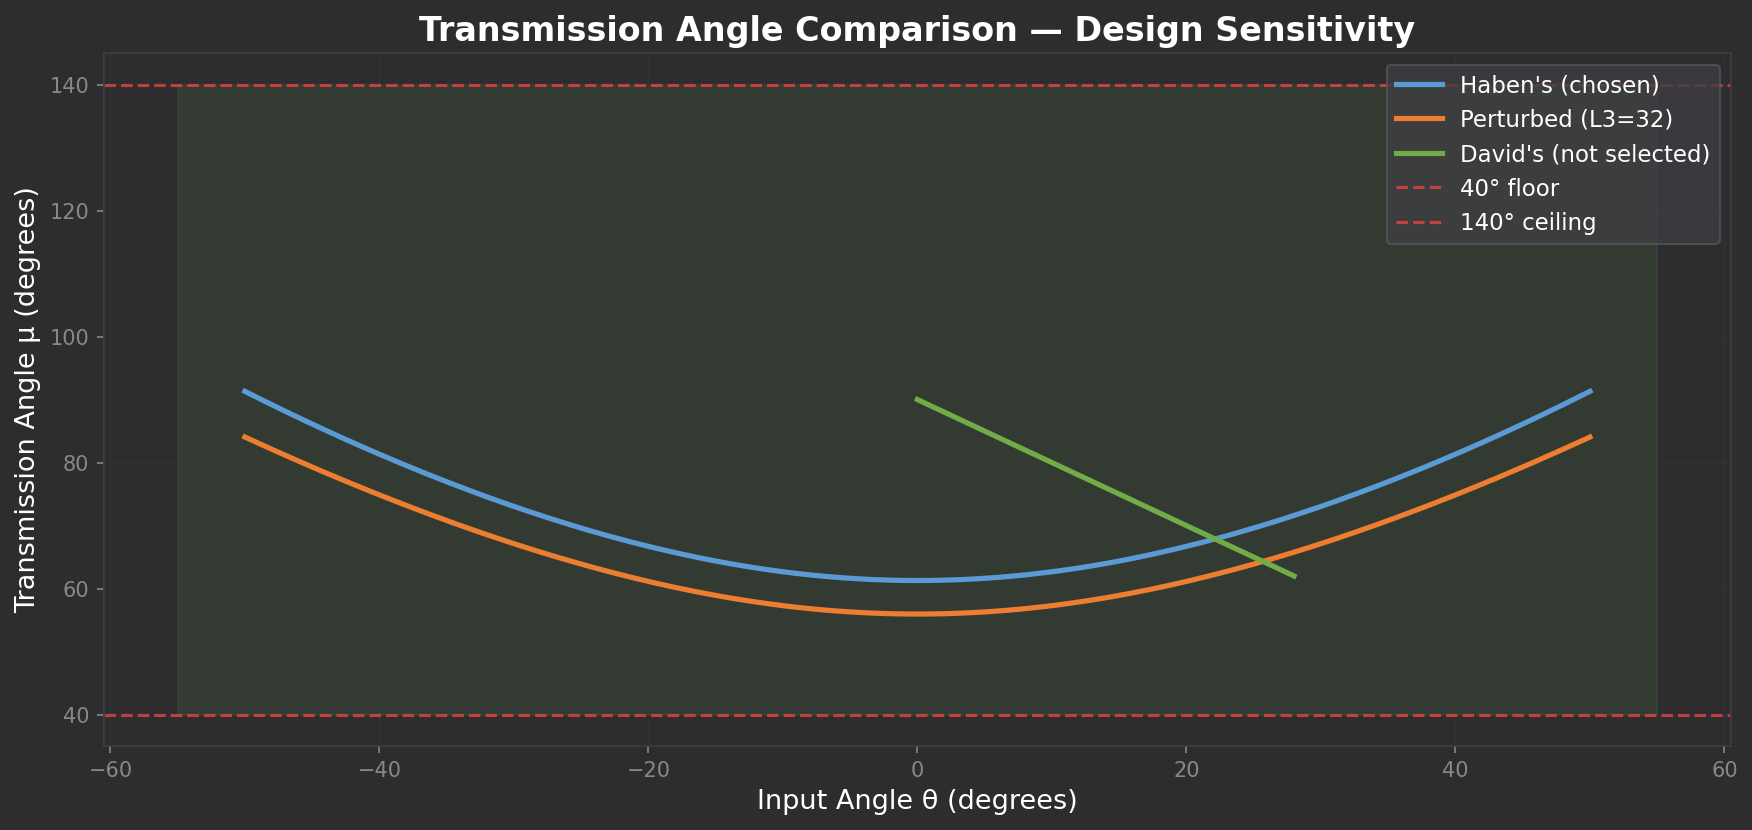

In [ ]:
# Transmission angle comparison across designs
fig, ax = plt.subplots(figsize=(14,6), facecolor='#2D2D30')
ax.set_facecolor('#2D2D30')

designs = {
    "Haben's (chosen)": (47,20,29,23, 47, -50, 50),
    'Perturbed (L3=32)': (47,20,32,23, 47, -50, 50),
    "David's (not selected)": (12,26,12,26, 0, 0, 28),
}
colors = ['#5B9BD5','#ED7D31','#70AD47']

for (name,(l1,l2,l3,l4,o4x,tmin,tmax)),c in zip(designs.items(),colors):
    ts = np.linspace(tmin,tmax,200)
    mus = []
    for t in ts:
        A = np.array([l2*np.cos(np.radians(t)), l2*np.sin(np.radians(t))])
        o4 = np.array([o4x, 12. if 'David' in name else 0.])
        dx,dy = o4[0]-A[0], o4[1]-A[1]
        d = np.sqrt(dx**2+dy**2)
        if d>l3+l4 or d<abs(l3-l4): mus.append(np.nan); continue
        cos_mu = np.clip((l3**2+l4**2-d**2)/(2*l3*l4),-1,1)
        mus.append(np.degrees(np.arccos(cos_mu)))
    ax.plot(ts, mus, color=c, lw=2.5, label=name)

ax.axhline(40,color='#FF4444',ls='--',lw=1.5,alpha=.7,label='40° floor')
ax.axhline(140,color='#FF4444',ls='--',lw=1.5,alpha=.7,label='140° ceiling')
ax.fill_between(np.linspace(-55,55,10),40,140,alpha=.1,color='#70AD47')
ax.set_xlabel('Input Angle θ (°)',fontsize=13,color='w')
ax.set_ylabel('Transmission Angle μ (°)',fontsize=13,color='w')
ax.set_title('Transmission Angle Comparison — Design Sensitivity',fontsize=16,fontweight='bold',color='w')
ax.legend(fontsize=11,loc='upper right',facecolor='#3E3E42',edgecolor='#555',labelcolor='w')
ax.tick_params(colors='#888'); ax.grid(True,color='#3E3E42',lw=.3,alpha=.5)
for s in ax.spines.values(): s.set_color('#3E3E42')
plt.tight_layout()
plt.show()


---## Key Takeaways| Design | μ Range | Margin Above 40° | Jaw Opening | Status ||--------|---------|-------------------|-------------|--------|| **Haben's (chosen)** | 61.3° – 91.3° | **21.3°** | 40.13 mm | Selected || Perturbed (L3=32) | 56.0° – 84.1° | 16.0° | 37.39 mm | Worse margin || David's | 76.7° – 76.7° | 36.7° | 25.16 mm | Below jaw target |> **"Changing one link length by 3 mm shifts the transmission angle band — the tool catches this instantly."**